In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
df = pd.read_csv("covid_grouped.csv")
print(df)

             Date      Country/Region  Confirmed  Deaths  Recovered  Active  \
0      2020-01-22         Afghanistan          0       0          0       0   
1      2020-01-22             Albania          0       0          0       0   
2      2020-01-22             Algeria          0       0          0       0   
3      2020-01-22             Andorra          0       0          0       0   
4      2020-01-22              Angola          0       0          0       0   
...           ...                 ...        ...     ...        ...     ...   
35151  2020-07-27  West Bank and Gaza      10621      78       3752    6791   
35152  2020-07-27      Western Sahara         10       1          8       1   
35153  2020-07-27               Yemen       1691     483        833     375   
35154  2020-07-27              Zambia       4552     140       2815    1597   
35155  2020-07-27            Zimbabwe       2704      36        542    2126   

       New cases  New deaths  New recovered        

In [55]:
df.head()

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region,iso_alpha
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean,AFG
1,2020-01-22,Albania,0,0,0,0,0,0,0,Europe,ALB
2,2020-01-22,Algeria,0,0,0,0,0,0,0,Africa,DZA
3,2020-01-22,Andorra,0,0,0,0,0,0,0,Europe,AND
4,2020-01-22,Angola,0,0,0,0,0,0,0,Africa,AGO


In [56]:
df.tail()

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region,iso_alpha
35151,2020-07-27,West Bank and Gaza,10621,78,3752,6791,152,2,0,Eastern Mediterranean,
35152,2020-07-27,Western Sahara,10,1,8,1,0,0,0,Africa,ESH
35153,2020-07-27,Yemen,1691,483,833,375,10,4,36,Eastern Mediterranean,YEM
35154,2020-07-27,Zambia,4552,140,2815,1597,71,1,465,Africa,ZMB
35155,2020-07-27,Zimbabwe,2704,36,542,2126,192,2,24,Africa,ZWE


In [57]:
df.shape

(35156, 11)

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35156 entries, 0 to 35155
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Date            35156 non-null  str  
 1   Country/Region  35156 non-null  str  
 2   Confirmed       35156 non-null  int64
 3   Deaths          35156 non-null  int64
 4   Recovered       35156 non-null  int64
 5   Active          35156 non-null  int64
 6   New cases       35156 non-null  int64
 7   New deaths      35156 non-null  int64
 8   New recovered   35156 non-null  int64
 9   WHO Region      35156 non-null  str  
 10  iso_alpha       35156 non-null  str  
dtypes: int64(7), str(4)
memory usage: 3.0 MB


In [59]:
df.dtypes

Date                str
Country/Region      str
Confirmed         int64
Deaths            int64
Recovered         int64
Active            int64
New cases         int64
New deaths        int64
New recovered     int64
WHO Region          str
iso_alpha           str
dtype: object

In [60]:
df.describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered
count,3.515600e+04,35156.000000,3.515600e+04,3.515600e+04,35156.00000,35156.000000,35156.000000
mean,2.356663e+04,1234.068239,1.104813e+04,1.128443e+04,469.36375,18.603339,269.315593
std,1.499818e+05,7437.238354,6.454640e+04,8.997149e+04,3005.86754,115.706351,2068.063852
min,0.000000e+00,0.000000,0.000000e+00,-2.000000e+00,0.00000,-1918.000000,-16298.000000
25%,1.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.00000,0.000000,0.000000
50%,2.500000e+02,4.000000,3.300000e+01,8.500000e+01,2.00000,0.000000,0.000000
75%,3.640250e+03,78.250000,1.286250e+03,1.454000e+03,75.00000,1.000000,20.000000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,77255.00000,3887.000000,140050.000000


In [61]:
df.isnull().sum()

Date              0
Country/Region    0
Confirmed         0
Deaths            0
Recovered         0
Active            0
New cases         0
New deaths        0
New recovered     0
WHO Region        0
iso_alpha         0
dtype: int64

In [62]:
df.duplicated().sum()

np.int64(0)

In [63]:
df.nunique()

Date                188
Country/Region      187
Confirmed         10732
Deaths             3598
Recovered          7649
Active             8440
New cases          2800
New deaths          715
New recovered      2276
WHO Region            6
iso_alpha           179
dtype: int64

In [64]:
print(df["Country/Region"].nunique())

187


1.How many rows and columns are present in the dataset?

In [65]:
rows, columns = df.shape
print("Total Rows :", rows)
print("Total Columns :", columns)

Total Rows : 35156
Total Columns : 11


2.Find the top 10 countries with the highest confirmed cases?Descending order.

In [66]:
top10_confirmed = (df.groupby("Country/Region")["Confirmed"].max().sort_values(ascending=False).head(10).reset_index())
print(top10_confirmed)

   Country/Region  Confirmed
0              US    4290259
1          Brazil    2442375
2           India    1480073
3          Russia     816680
4    South Africa     452529
5          Mexico     395489
6            Peru     389717
7           Chile     347923
8  United Kingdom     301708
9            Iran     293606


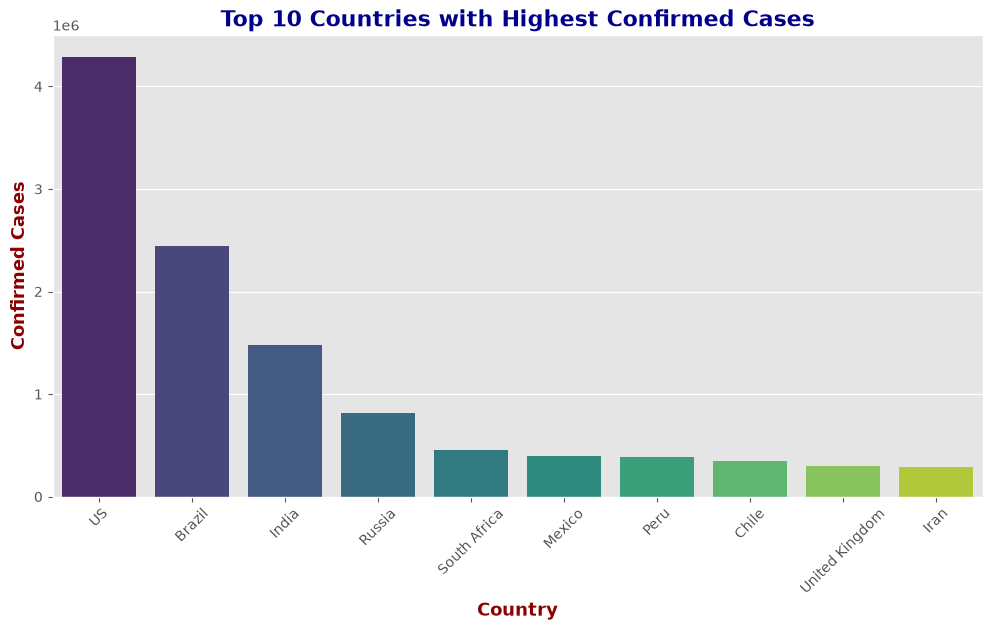

In [67]:
plt.figure(figsize=(12,6))
sns.barplot(data=top10_confirmed,
    x="Country/Region",
    y="Confirmed",
    hue="Country/Region",
    palette="viridis"
    )
plt.title("Top 10 Countries with Highest Confirmed Cases", fontsize=16, color="darkblue", fontweight="bold")
plt.xlabel("Country", fontsize=13, color="darkred", fontweight="bold")
plt.ylabel("Confirmed Cases", fontsize=13, color="darkred", fontweight="bold")
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.show()

3.Which country has the highest number of deaths?

In [68]:
top10_deaths = (df.groupby("Country/Region")["Deaths"].max().sort_values(ascending=False).head(10).reset_index())
print(top10_deaths)

   Country/Region  Deaths
0              US  148011
1          Brazil   87618
2  United Kingdom   45844
3          Mexico   44022
4           Italy   35112
5           India   33408
6          France   30212
7           Spain   28752
8            Peru   18418
9            Iran   15912


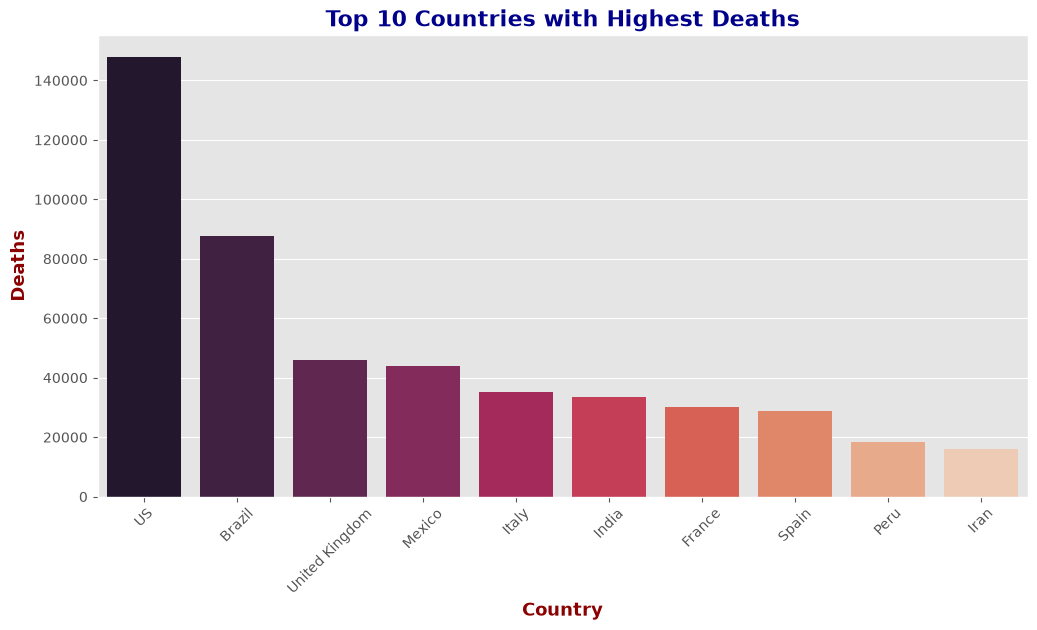

In [69]:
plt.figure(figsize=(12,6))
sns.barplot(data=top10_deaths,
    x="Country/Region",
    y="Deaths",
    hue="Country/Region",
    palette="rocket"
    )
plt.title("Top 10 Countries with Highest Deaths", fontsize=16, color="darkblue", fontweight="bold")
plt.xlabel("Country", fontsize=13, color="darkred", fontweight="bold")
plt.ylabel("Deaths", fontsize=13, color="darkred", fontweight="bold")
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.show()

4.Find the total number of confirmed, deaths, and recovered cases worldwide.

In [70]:
latest = (df.groupby("Country/Region")[["Confirmed","Deaths","Recovered"]].max())

confirmed = latest["Confirmed"].sum()
deaths = latest["Deaths"].sum()
recovered = latest["Recovered"].sum()

print("Worldwide Confirmed Cases :", confirmed)
print("Worldwide Death Cases :", deaths)
print("Worldwide Recovered Cases :", recovered)

Worldwide Confirmed Cases : 16480536
Worldwide Death Cases : 654358
Worldwide Recovered Cases : 9483738


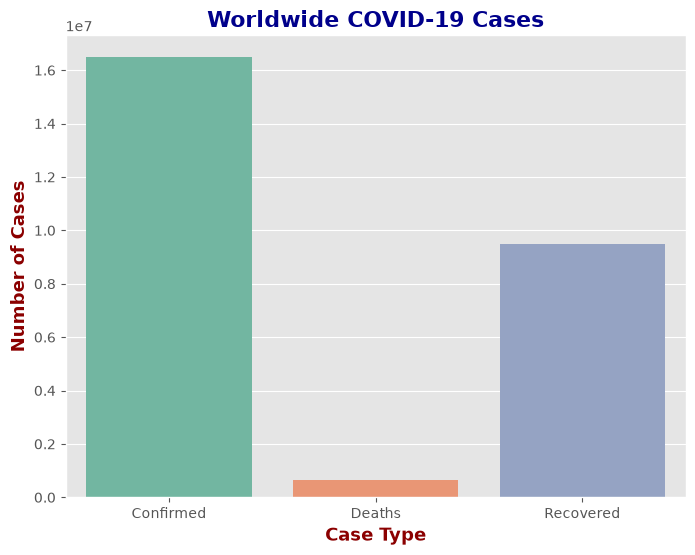

In [71]:
world = pd.DataFrame({
    "Case Type": ["Confirmed", "Deaths", "Recovered"],
    "Cases": [confirmed, deaths, recovered]
})
plt.figure(figsize=(8,6))
sns.barplot(
    data=world,
    x="Case Type",
    y="Cases",
    hue="Case Type",
    palette="Set2"
)
plt.title("Worldwide COVID-19 Cases", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("Case Type", fontsize=13, fontweight="bold", color="darkred")
plt.ylabel("Number of Cases", fontsize=13, fontweight="bold", color="darkred")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

5.How many unique WHO Regions are present in the dataset?

In [72]:
regions = df["WHO Region"].nunique()
print("Total WHO Regions :", regions)

Total WHO Regions : 6


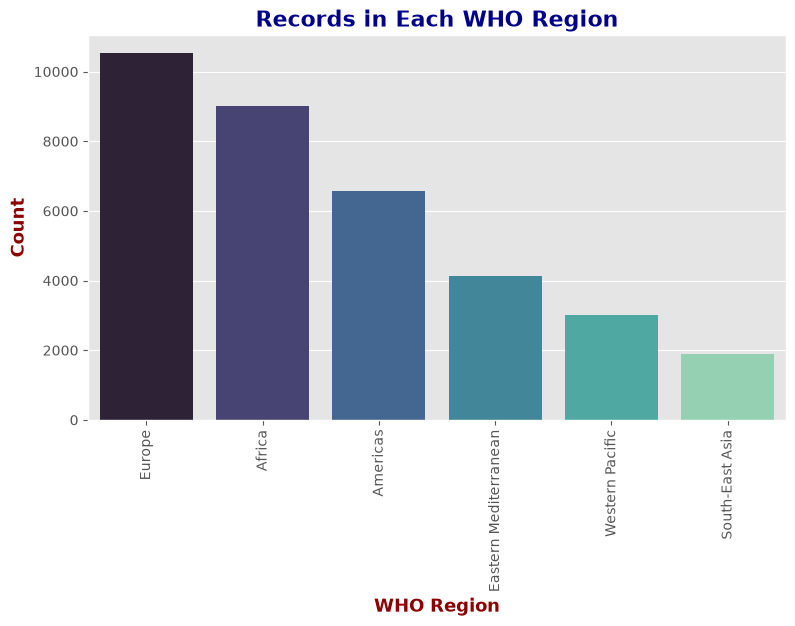

In [73]:
region_count = df["WHO Region"].value_counts().reset_index()
region_count.columns = ["WHO Region", "Count"]

plt.figure(figsize=(9,5))
sns.barplot(
    data=region_count,
    x="WHO Region",
    y="Count",
    hue="WHO Region",
    palette="mako"
)
plt.title("Records in Each WHO Region", fontsize=16, fontweight="bold", color="darkblue")
plt.xlabel("WHO Region", fontsize=13, fontweight="bold", color="darkred")
plt.ylabel("Count", fontsize=13, fontweight="bold", color="darkred")
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.show()

6.Create a bar chart of the top 10 countries with the highest confirmed cases.

In [80]:
top10_confirmed = (df.groupby("Country/Region", as_index=False)["Confirmed"].max().sort_values(by="Confirmed", ascending=False).head(10))
print(top10_confirmed)

     Country/Region  Confirmed
173              US    4290259
23           Brazil    2442375
79            India    1480073
138          Russia     816680
154    South Africa     452529
111          Mexico     395489
132            Peru     389717
35            Chile     347923
177  United Kingdom     301708
81             Iran     293606


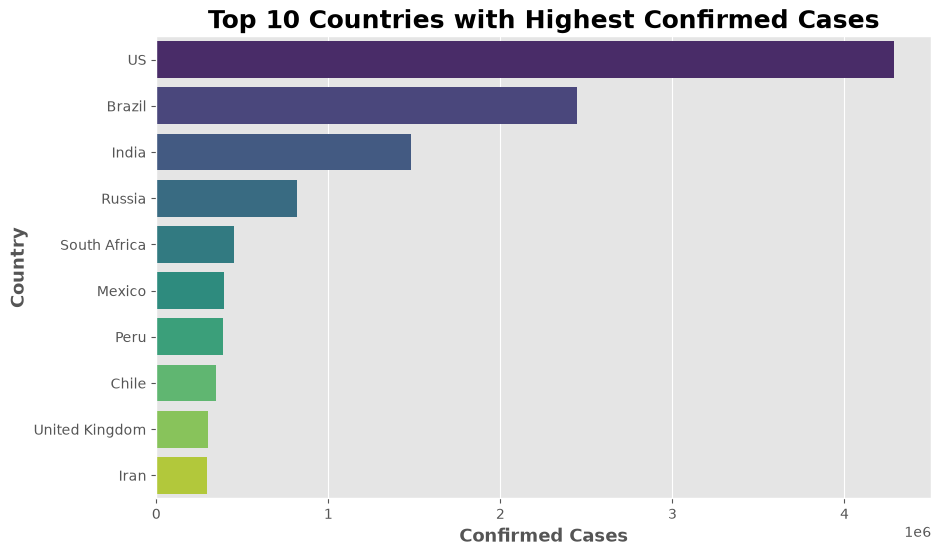

In [82]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_confirmed,
    x="Confirmed",
    y="Country/Region",
    hue="Country/Region",
    palette="viridis"
)
plt.title("Top 10 Countries with Highest Confirmed Cases", fontsize=18, fontweight="bold")
plt.xlabel("Confirmed Cases", fontsize=13, fontweight="bold")
plt.ylabel("Country", fontsize=13, fontweight="bold")

plt.show()

7.Create a pie chart showing confirmed cases by WHO Region.

In [ ]:
no_of_unique_WHO_regions = df["WHO Region"].nunique()
print(f"Number of unique WHO regions : {no_of_unique_WHO_regions}") 

Number of unique WHO regions : 6


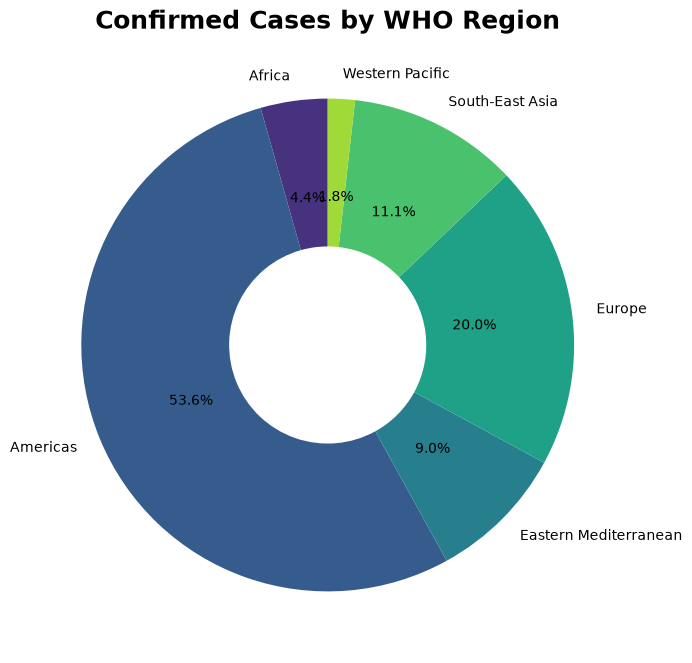

In [ ]:
region = (latest.groupby("WHO Region")["Confirmed"].sum())
plt.figure(figsize=(8,8))
colors = sns.color_palette("viridis")
plt.pie(
    region,
    labels=region.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"width":0.60}
)
plt.title("Confirmed Cases by WHO Region",fontsize=18,fontweight="bold")
plt.show()

8.Plot a line chart showing confirmed cases over time.

In [ ]:
daily_cases = (df.groupby("Date")["Confirmed"].sum())
print(daily_cases)

Date
2020-01-22         555
2020-01-23         654
2020-01-24         941
2020-01-25        1434
2020-01-26        2118
                ...   
2020-07-23    15510481
2020-07-24    15791645
2020-07-25    16047190
2020-07-26    16251796
2020-07-27    16480485
Name: Confirmed, Length: 188, dtype: int64


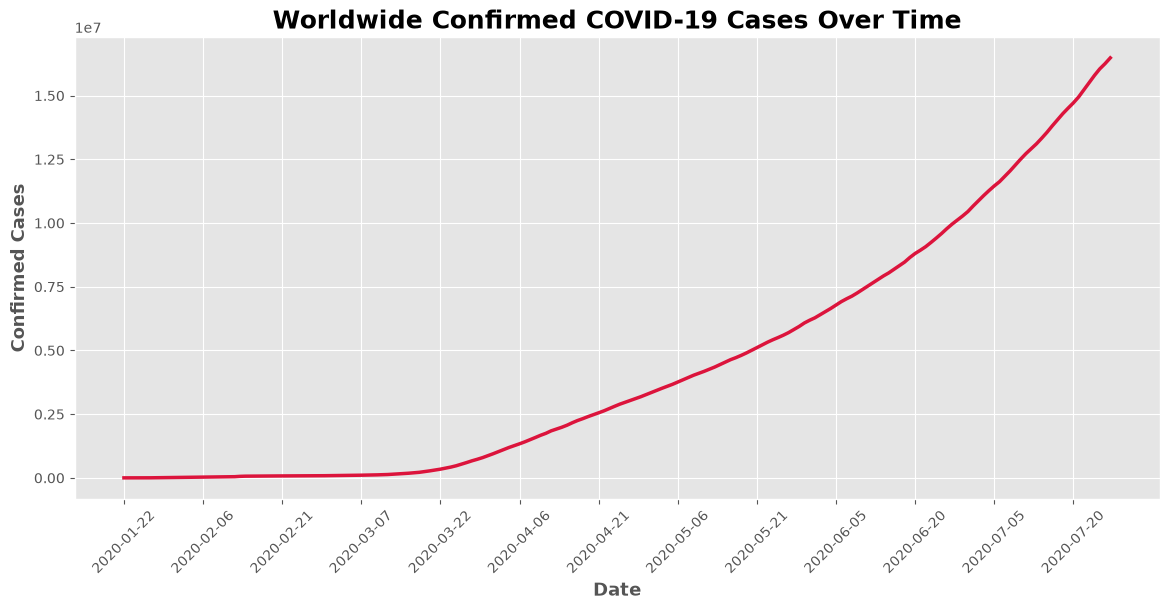

In [ ]:
daily_cases = (df.groupby("Date")["Confirmed"].sum())
plt.figure(figsize=(14,6))
sns.lineplot(
    x=daily_cases.index,
    y=daily_cases.values,
    color="crimson",
    linewidth=2.5
)
plt.title("Worldwide Confirmed COVID-19 Cases Over Time", fontsize=18, fontweight="bold")
plt.xlabel("Date", fontsize=13, fontweight="bold")
plt.ylabel("Confirmed Cases", fontsize=13, fontweight="bold")
plt.xticks(daily_cases.index[::15], rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.show()

9.Plot a histogram of confirmed cases.

In [ ]:
scatter_data = df[["Confirmed", "Deaths"]]
print(scatter_data.head())

   Confirmed  Deaths
0          0       0
1          0       0
2          0       0
3          0       0
4          0       0


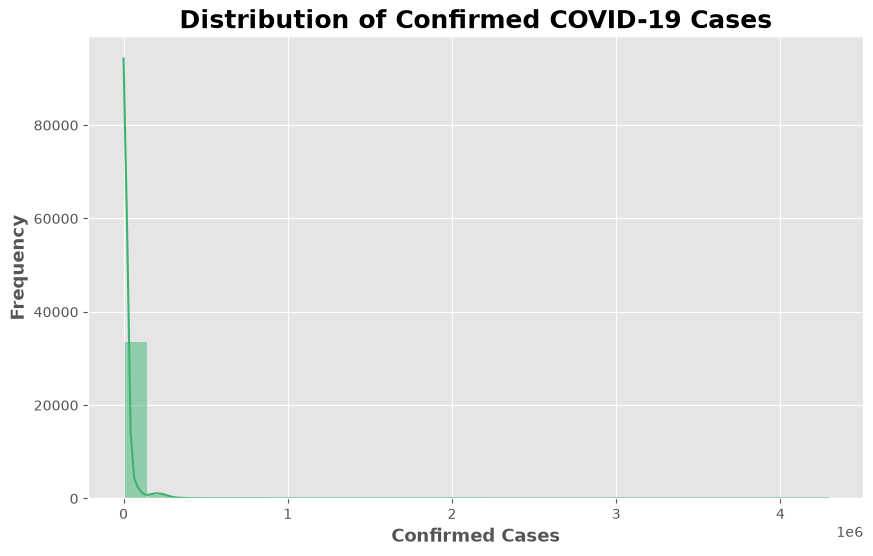

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="Confirmed",
    bins=30,
    kde=True,
    color="mediumseagreen"
)
plt.title("Distribution of Confirmed COVID-19 Cases", fontsize=18, fontweight="bold")
plt.xlabel("Confirmed Cases", fontsize=13, fontweight="bold")
plt.ylabel("Frequency", fontsize=13, fontweight="bold")
plt.show()

10.Create a scatter plot between confirmed cases and deaths.

In [ ]:
latest = (df.groupby(["Country/Region", "WHO Region"])[["Confirmed", "Deaths"]].max().reset_index())
print(latest.head())

  Country/Region             WHO Region  Confirmed  Deaths
0    Afghanistan  Eastern Mediterranean      36263    1269
1        Albania                 Europe       4880     144
2        Algeria                 Africa      27973    1163
3        Andorra                 Europe        907      52
4         Angola                 Africa        950      41


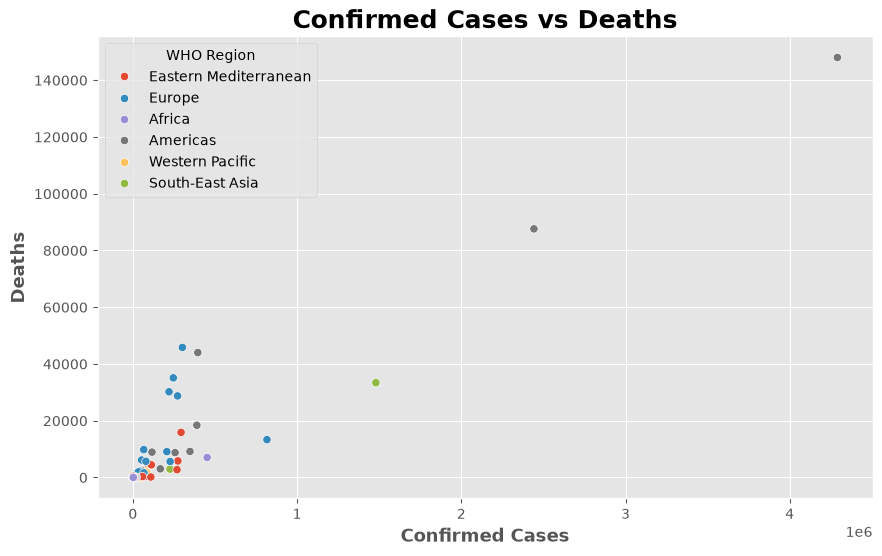

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=latest,
    x="Confirmed",
    y="Deaths",
    hue="WHO Region"
)

plt.title("Confirmed Cases vs Deaths",fontsize=18,fontweight="bold")
plt.xlabel("Confirmed Cases", fontsize=13, fontweight="bold")
plt.ylabel("Deaths", fontsize=13, fontweight="bold")
plt.show()